## Bayesian estimates of (Mr, [Fe/H], Ar) using SDSS colors and TRILEGAL priors

### speed: from 0.1-0.2 sec/star for full locus resolution to 10 millisec for sparse locus

### (with known Ar: 2D version runs in 4 milisec/star)

### using TRILEGAL-based catalog for SDSSpatchRA340-350 and 3D Bayes for Karlo's tests...

In [1]:
%matplotlib inline
import sys
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import hstack
import matplotlib.pyplot as plt 
import numpy as np
from scipy import stats
from scipy import optimize
from scipy.stats import gaussian_kde
# from scipy import interpolate 
from scipy.interpolate import griddata

In [2]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2
# importing plotting and locus tools: 
sys.path.append('../src')
import LocusTools as lt
import BayesTools as bt
import PlotTools as pt

### read stellar locus parametrization

In [3]:
datafile = '../data/LocusData/SDSSDSEDlocus_10Gyr.txt'
OKlocus = lt.readSDSSDSEDlocus(datafile, fixForStripe82=False)
### hack to switch to tLoc implementation
OKlocus['MrTrue'] = OKlocus['Mr']
OKlocus['Mr'] = OKlocus['tLoc']
print(np.min(OKlocus['MrTrue']), np.max(OKlocus['MrTrue']))
print(np.min(OKlocus['Mr']), np.max(OKlocus['Mr']))

-3.03 15.99
1.4 15.99


In [4]:
### 
priorsRootName = '../data/AstroLabPriors/Stripe82/SDSSpatchRA340-350-priorMap'
if (1):
    # maximum resolution version
    locusData = OKlocus  
    outfile = '../data/outputs/SDSSpatchRA340-350_BayesEstimates3D_LovroGPUtest.txt' 
else:
    ## subsample Mr and FeH grids (linear speed-up but somewhat lower accuracy)
    kMr = 10
    kFeH = 2 
    locusData = lt.subsampleLocusData(OKlocus, kMr, kFeH)
    outfile = '../data/outputs/SDSSpatchRA340-350_BayesEstimates3D_LovroGPUtest_sparse10-2.txt' 

In [5]:
### make 3D locus list with three ArGrid limits and resolutions
timeStart = !date +%s  
fitColors = ('ug', 'gr', 'ri', 'iz')  
ArGridList, locus3DList = lt.get3DmodelList(locusData, fitColors, agressive=False, DSED=True)
timeEnd = !date +%s  
runTime = int(timeEnd[0])-int(timeStart[0])
print('Made model locus3D list in', runTime,'seconds.')

Made model locus3D list in 64 seconds.


### read photometric catalog with stars

In [8]:
## read TRILEGAL-based data file, augmented with LSST colors 
# catFile = '../data/AstroLabPriors/Stripe82/SDSSpatchRA340-350-simLSSTcatalog.txt'
catFile = 'SmallSample_MSblue.txt'
sims = lt.readTRILEGALLSST(inTLfile=catFile, chiTest=True)
sims[0:2]
print(np.min(sims['Mr']), np.max(sims['Mr'])) 

READING FROM SmallSample_MSblue.txt
8 read from SmallSample_MSblue.txt
5.01 5.17


In [9]:
simsOK = sims[sims['logg']<6.5]
print('Mr:', np.min(simsOK['Mr']), np.max(simsOK['Mr'])) 
print('Ar:', np.min(simsOK['Ar']), np.max(simsOK['Ar'])) 

Mr: 5.01 5.17
Ar: 0.15 0.21


Text(0, 0.5, 'lat')

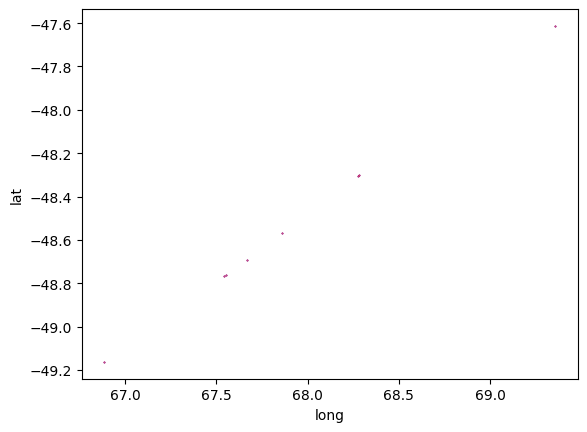

In [10]:
plt.scatter(sims['glon'], sims['glat'], c='blue', s=0.1)   
plt.scatter(simsOK['glon'], simsOK['glat'], c='red', s=0.1)   
plt.xlabel('long')
plt.ylabel('lat')

Text(0, 0.5, 'Ar')

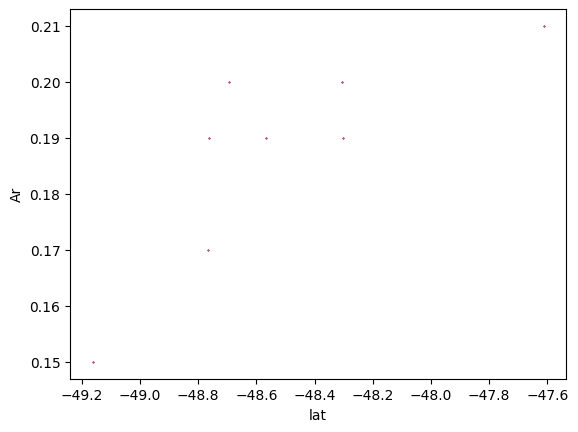

In [11]:
plt.scatter(sims['glat'], sims['Ar'], c='blue', s=0.1)   
plt.scatter(simsOK['glat'], simsOK['Ar'], c='red', s=0.1)   
plt.xlabel('lat')
plt.ylabel('Ar')

## process data...

In [12]:
C = lt.extcoeff()
reddCoeffs = {}
reddCoeffs['ug'] = C['u']-C['g']
reddCoeffs['gr'] = C['g']-C['r']
reddCoeffs['ri'] = C['r']-C['i']
reddCoeffs['iz'] = C['i']-C['z']

Mr1d= 1.4 15.99 1459
MrBright, MrFaint= 1.4 15.99
working on star 0
pts: 31 1459


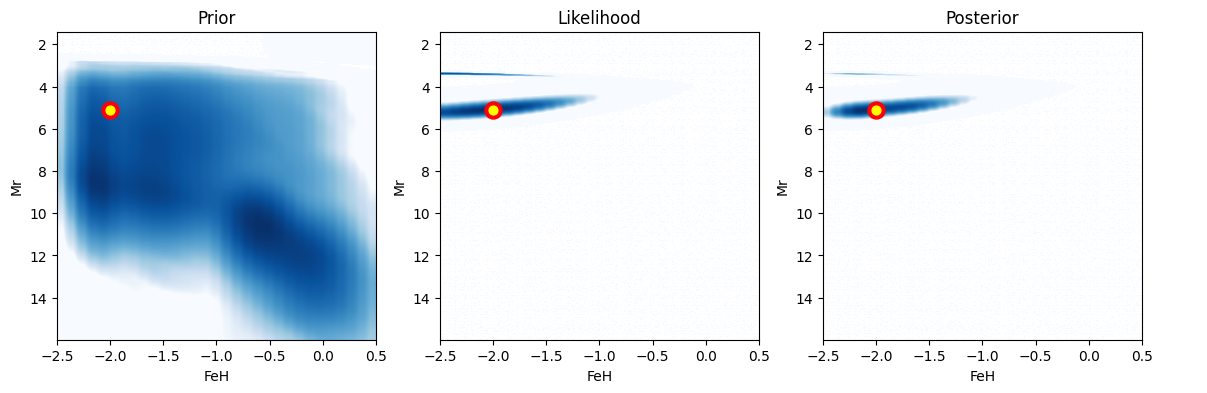

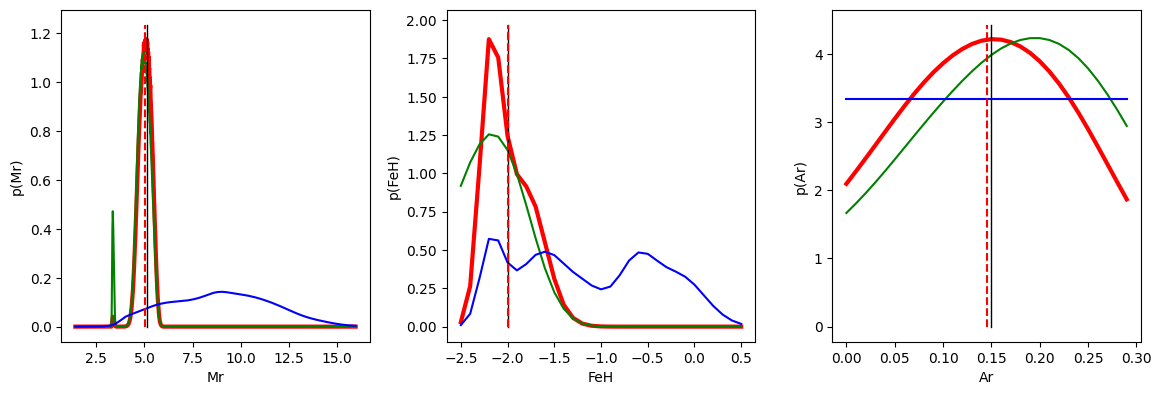

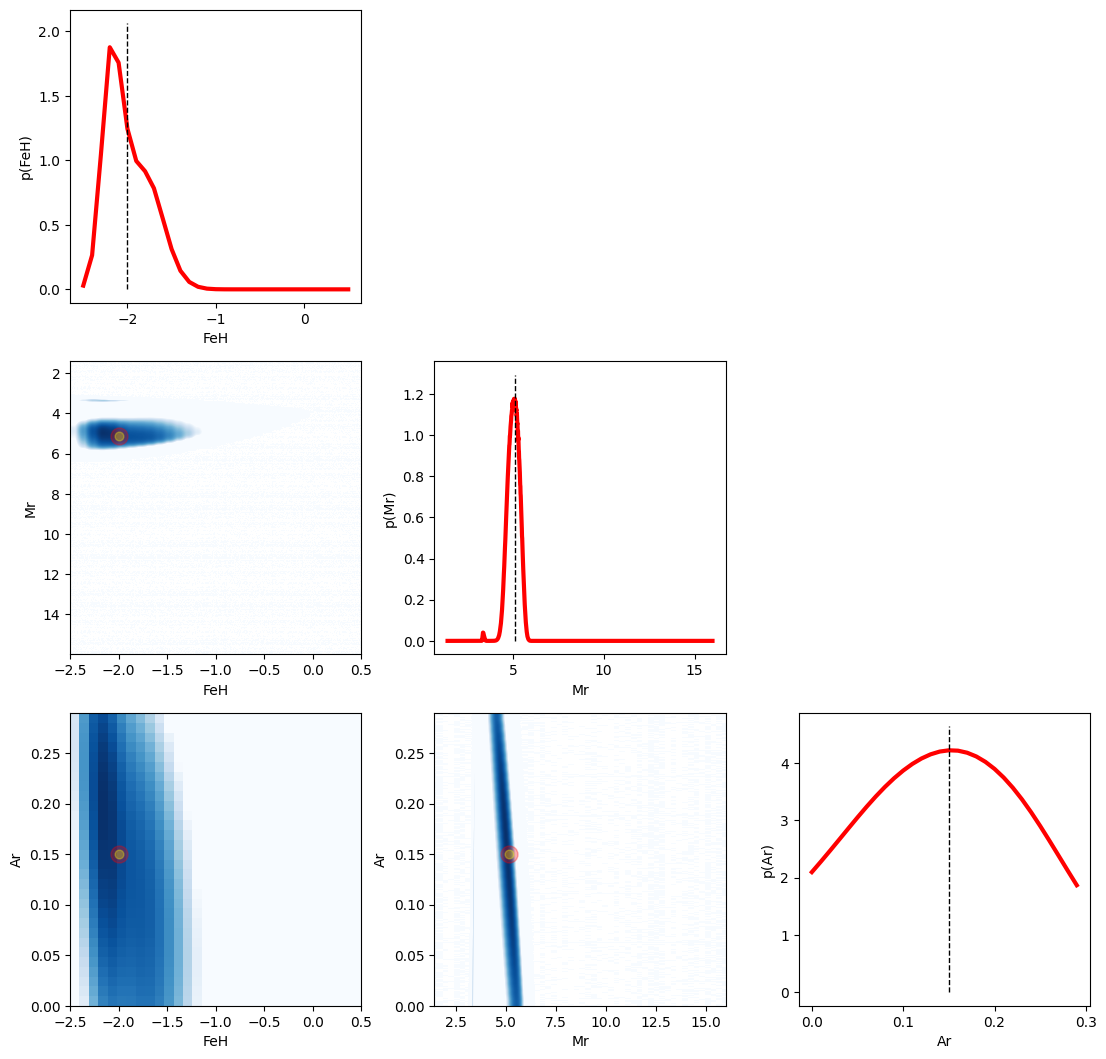

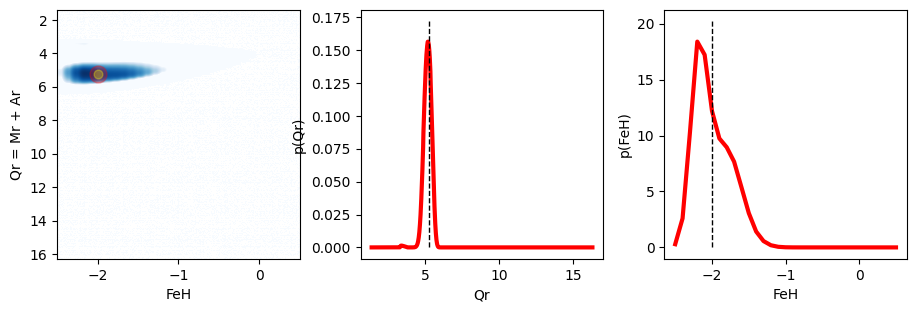

 *** 3D Bayes results for star i= 0
r mag: 23.13 g-r: 0.369 chi2min: 1.496710537502308
Mr: true= 5.12 estimate= 5.033871355832761  +-  0.3226275125582905
FeH: true= -2.0 estimate= -1.9942895632284579  +-  0.24853271830102322
Ar: true= 0.15 estimate= 0.14502479545313132  +-  0.07765531878003794
Qr: true= 5.2700000000000005 estimate= 5.173996419104585  +-  0.26512703677385985
Mr drop in entropy: -305.37389948231345
FeH drop in entropy: -14.88673147267942
Ar drop in entropy: -3.664539724767309
Finished in 6 seconds.


In [20]:
catalog = sims
iStart = 0   #  
iEnd = 1    # if <0: do all stars
myStars = [0] # no plots when measuring speed
verb=True
    
timeStart = !date +%s  
bt.makeBayesEstimates3D(catalog, fitColors, locusData, locus3DList, ArGridList, priorsRootName, outfile, \
                           iStart, iEnd, myStars, verbose=verb, MrColumn='MrTrue')
timeEnd = !date +%s  
runTime = int(timeEnd[0])-int(timeStart[0])
print('Finished in', runTime, 'seconds.')

In [20]:
# TAKE small cube in color space and plot Mr vs. FeH diagram
# from SDSSDSEDlocus_10Gyr.txt 
# tLoc    Mr    FeH     ug      gr      ri      iz   
# 3.53   3.06 -1.90   0.854   0.225   0.071  -0.007
# 4.15   4.15 -1.80   0.828   0.231   0.070  -0.009
# 
# Above: why is the max likelihood always below the truth?? tLoc!!! 

In [21]:
# for processed stars
if (iEnd < iStart):
    iStart = 0
    iEnd = np.size(catalog)
mytableAll = catalog[iStart:iEnd]

In [22]:
# reject WDs by logg
mytable = mytableAll[mytableAll['logg']<6.5]
print('selected', len(mytable), ' from', len(mytableAll))

selected 609882  from 619581


In [23]:
has_nan = np.zeros(len(mytable), dtype=bool)
for col in mytable.itercols():
    if col.info.dtype.kind == 'f':
        has_nan |= np.isnan(col)
simsP = mytable[(~has_nan)&(mytable['chi2min']<100)&(mytable['FeHEstUnc']>0.001)]
bad = mytable[has_nan]
print('selected', len(simsP), ' from', len(mytable),' bad:', len(bad))

selected 609809  from 609882  bad: 0


In [24]:
simsP['dMr'] = simsP['Mr'] - simsP['MrEst']
simsP['dMrNorm'] = simsP['dMr'] / simsP['MrEstUnc'] 
simsP['dFeH'] = simsP['FeH'] - simsP['FeHEst']
simsP['dFeHNorm'] = simsP['dFeH'] / simsP['FeHEstUnc'] 
simsP['dAr'] = simsP['Ar'] - simsP['ArEst']
simsP['dArNorm'] = simsP['dAr'] / simsP['ArEstUnc'] 
print('sample size:', np.size(simsP))
print('Mr  FeH  Ar:')
print('median uncertainty:', np.median(simsP['MrEstUnc']), np.median(simsP['FeHEstUnc']), np.median(simsP['ArEstUnc']))
print('median error:', np.median(simsP['dMr']), np.median(simsP['dFeH']), np.median(simsP['dAr']))
print('std for chi:', np.std(simsP['dMrNorm']), np.std(simsP['dFeHNorm']), np.std(simsP['dArNorm']))
print('sigG for chi:', bt.sigGzi(simsP['dMrNorm']), bt.sigGzi(simsP['dFeHNorm']), bt.sigGzi(simsP['dArNorm']))

sample size: 609809
Mr  FeH  Ar:
median uncertainty: 0.3417097489738404 0.4487057762412814 0.07959779514815178
median error: 0.0016178435174936112 0.0008380729602222581 0.008715668750159361
std for chi: 7.240093213588023 1.0264855654581595 0.7069062934473832
sigG for chi: 0.8979529007594185 0.9989759522802788 0.4464458262121472


In [18]:
## no subsampling for SDSSpatchRA340-350-simLSSTcatalog.txt
# sample size: 621804
# Mr  FeH  Ar:
# median uncertainty: 0.3492578723066983 0.44967075411150004 0.07947191218860651
# median error: 0.009230786548643177 0.003984462666541511 0.008667234348163577
# std for chi: 14.696513544842848 8.388418081595196 1.2109199043173913
# sigG for chi: 0.9062474271946606 1.0268082104707972 0.44774171285423114

In [25]:
outfile = '../data/outputs/SDSSpatchRA340-350_BayesEstimates3D-KarloNNtest.txt'
print(iStart, iEnd)

0 619581


In [26]:
bt.writeBayesEstimates(catalog, outfile, iStart, iEnd, do3D=True)

### correct for Mr < 4 projection of Mr to tLoc

In [27]:
# overwrite MrEst that are nan
has_nanCAT = np.zeros(len(catalog), dtype=bool)
for col in catalog.itercols():
    if col.info.dtype.kind == 'f':
        has_nanCAT |= np.isnan(col)
catalog['MrEst'] = np.where(has_nanCAT, 99.99, catalog['MrEst'])

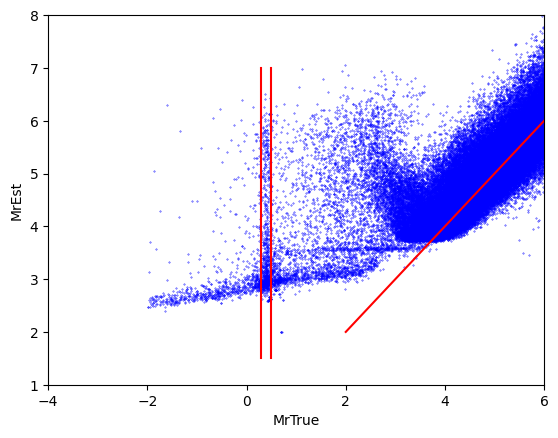

In [28]:
plt.scatter(catalog['Mr'], catalog['MrEst'], c='blue', s=0.1)  
plt.xlabel('MrTrue')
plt.ylabel('MrEst')
plt.plot([2,6], [2,6], c='red')
plt.xlim(-4, 6)
plt.ylim(1, 8)

plt.plot([0.3,0.3], [1.5, 7], c='red')
plt.plot([0.5,0.5], [1.5, 7], c='red')

## correct for tLoc vs. Mr mapping

In [29]:
catalog['tLoc'] = catalog['MrEst']
lt.getMrFromFeHtLoc(OKlocus, catalog)

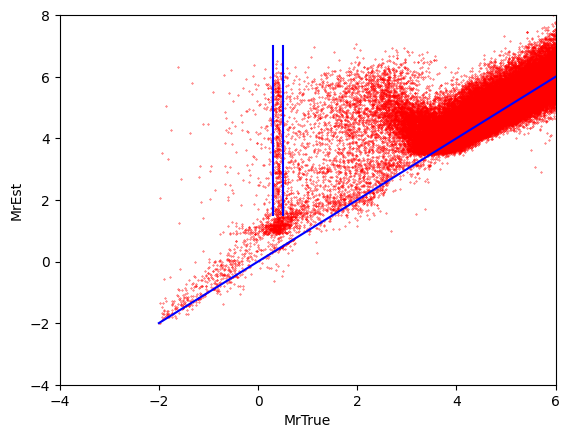

In [30]:
# test result
plt.scatter(catalog['Mr'], catalog['MrTrueEst'], c='red', s=0.1)  
plt.xlabel('MrTrue')
plt.ylabel('MrEst')
plt.plot([-2,6], [-2,6], c='blue')
plt.xlim(-4, 6)
plt.ylim(-4, 8) 
plt.plot([0.3,0.3], [1.5, 7], c='blue')
plt.plot([0.5,0.5], [1.5, 7], c='blue')

In [31]:
print(outfile)

../data/outputs/SDSSpatchRA340-350_BayesEstimates3D-KarloNNtest.txt


In [32]:
## overwrite
catalog['MrEst'] = catalog['MrTrueEst']
bt.writeBayesEstimates(catalog, outfile, iStart, iEnd, do3D=True)

In [33]:
mytable = catalog
has_nan = np.zeros(len(mytable), dtype=bool)
for col in mytable.itercols():
    if col.info.dtype.kind == 'f':
        has_nan |= np.isnan(col)
simsP = mytable[(~has_nan)&(mytable['chi2min']<100)&(mytable['FeHEstUnc']>0.001)]
bad = mytable[has_nan]
print('selected', len(simsP), ' from', len(mytable),' bad:', len(bad))

selected 617773  from 619581  bad: 722


In [34]:
simsP[0:2]

glon,glat,comp,logg,FeH,Mr,DM,Ar,rmag0,ug0,gr0,ri0,iz0,rmag,ug,gr,ri,iz,uErr,gErr,rErr,iErr,zErr,ugSL,grSL,riSL,izSL,ugErrSL,grErrSL,riErrSL,izErrSL,gi0,gi,gmag,umag,imag,zmag,ugErr,grErr,riErr,izErr,MrEst,MrEstUnc,FeHEst,FeHEstUnc,ArEst,ArEstUnc,QrEst,QrEstUnc,chi2min,MrdS,FeHdS,ArdS,tLoc,MrTrueEst
float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
66.50259548,-49.4174074,3,4.96,-0.43,10.51,12.8,0.14,23.45,2.699,1.469,1.149,0.632,23.44,2.756,1.525,1.183,0.659,1.23,0.037,0.012,0.008,0.009,2.665,1.446,1.201,0.642,1.059,0.037,0.014,0.012,2.6180000000000003,2.708,24.965,27.721,22.257,21.598000000000003,1.23055637822897,0.03889730067755345,0.014422205101855958,0.012041594578792296,10.65,0.3258927851034502,-0.7301318559681185,0.4258569259762971,0.24000645857933933,0.03803375045498303,-99.0,-1.0,1.47339390471832,-310.88210930167827,-8.802739949177992,-127.0597195968831,10.648102263735433,10.65
66.48529696,-49.39598389,1,4.75,-0.65,8.53,8.25,0.15,16.93,2.596,1.334,0.628,0.354,16.94,2.657,1.394,0.664,0.384,0.008,0.005,0.005,0.005,0.005,2.643,1.397,0.663,0.373,0.009,0.007,0.007,0.007,1.9620000000000002,2.058,18.334,20.991,16.276,15.892,0.009433981132056603,0.007071067811865475,0.007071067811865475,0.007071067811865475,8.4,0.08118345903273583,-0.41167447834938686,0.11063623731406841,0.12992837086416595,0.028038709127696963,-99.0,-1.0,2.3176828089887946,-433.31844008530936,-19.626816094533357,-137.6625064873537,8.399213940801754,8.4


In [41]:
## store in a data file  
outfile = '../data/outputs/BayesMethod3D_SDSSpatchRA340-350_KarloTest.txt'
## need to change defaults for bad mags and errors
bands = ['u', 'g', 'r', 'i', 'z']
tGood4sims = simsP
for b in bands:
    tGood4sims[b+'mag'] = np.where(simsP[b+'mag'] > 99.999, 99.999, simsP[b+'mag'])
    tGood4sims[b+'Err'] = np.where(simsP[b+'Err'] > 99.999, 99.999, simsP[b+'Err'])
# write
fout = open(outfile, "w")
fout.write("      gLon       gLat    ArSFD  ")
fout.write("umag   gmag   rmag   imag   zmag")
fout.write("   uerr   gerr   rerr   ierr   zerr")
fout.write("   MrEst   MrUnc   FeHEst  FeHUnc   ArEst   ArUnc  chi2min")
fout.write("  MrTrue  FeHTrue ArTrue \n")
# for i in range(0,10):
for i in range(0,np.size(tGood4sims)):
    # input values from TRILEGAL
    r1 = tGood4sims['glon'][i]
    r2 = tGood4sims['glat'][i]
    r3 = tGood4sims['Ar'][i]  
    s = str("%12.7f" % r1) + str("%12.7f" % r2) + str("%6.2f" % r3)  
    # observed mags 
    r1 = tGood4sims['rmag'][i] + tGood4sims['gr'][i] + tGood4sims['ug'][i]
    r2 = tGood4sims['rmag'][i] + tGood4sims['gr'][i] 
    r3 = tGood4sims['rmag'][i]
    r4 = tGood4sims['rmag'][i] - tGood4sims['ri'][i] 
    r5 = tGood4sims['rmag'][i] - tGood4sims['ri'][i] - tGood4sims['iz'][i] 
    s = s + str("%7.3f" % r1) + str("%7.3f" % r2) + str("%7.3f" % r3) + str("%7.3f" % r4) + str("%7.3f" % r5)
    # errors for observed mags 
    r1 = tGood4sims['uErr'][i]
    r2 = tGood4sims['gErr'][i]
    r3 = tGood4sims['rErr'][i]
    r4 = tGood4sims['iErr'][i]
    r5 = tGood4sims['zErr'][i]
    s = s + str("%7.3f" % r1) + str("%7.3f" % r2) + str("%7.3f" % r3) + str("%7.3f" % r4) + str("%7.3f" % r5)
    # Bayes outputs 
    r1 = tGood4sims['MrEst'][i] 
    r2 = tGood4sims['MrEstUnc'][i] 
    s = s + str("%8.3f" % r1) + str("%8.3f" % r2)  
    r1 = tGood4sims['FeHEst'][i] 
    r2 = tGood4sims['FeHEstUnc'][i] 
    s = s + str("%8.3f" % r1) + str("%8.3f" % r2)  
    r1 = tGood4sims['ArEst'][i] 
    r2 = tGood4sims['ArEstUnc'][i] 
    s = s + str("%8.3f" % r1) + str("%8.3f" % r2)  
    r1 = tGood4sims['chi2min'][i] 
    s = s + str("%8.3f" % r1)  
    # true values
    r1 = tGood4sims['Mr'][i] 
    r2 = tGood4sims['FeH'][i] 
    r3 = tGood4sims['Ar'][i] 
    s = s + str("%8.3f" % r1) + str("%8.3f" % r2) + str("%8.3f" % r3)  
    s = s + "\n"
    fout.write(s)             
fout.close() 

## testing, should be moved elsewhere...

In [42]:
simsP['dMr'] = simsP['Mr'] - simsP['MrEst']
simsP['dMrNorm'] = simsP['dMr'] / simsP['MrEstUnc'] 
simsP['dFeH'] = simsP['FeH'] - simsP['FeHEst']
simsP['dFeHNorm'] = simsP['dFeH'] / simsP['FeHEstUnc'] 
simsP['dAr'] = simsP['Ar'] - simsP['ArEst']
simsP['dArNorm'] = simsP['dAr'] / simsP['ArEstUnc'] 
print('sample size:', np.size(simsP))
print('Mr  FeH  Ar:')
print('median uncertainty:', np.median(simsP['MrEstUnc']), np.median(simsP['FeHEstUnc']), np.median(simsP['ArEstUnc']))
print('median error:', np.median(simsP['dMr']), np.median(simsP['dFeH']), np.median(simsP['dAr']))
print('std for chi:', np.std(simsP['dMrNorm']), np.std(simsP['dFeHNorm']), np.std(simsP['dArNorm']))
print('sigG for chi:', bt.sigGzi(simsP['dMrNorm']), bt.sigGzi(simsP['dFeHNorm']), bt.sigGzi(simsP['dArNorm']))

sample size: 617773
Mr  FeH  Ar:
median uncertainty: 0.34243101324193964 0.4484914856572643 0.07970173000755525
median error: 0.009999999999999787 0.005603915748538579 0.008850565064312504
std for chi: 3.9694805196362544 4.434242335093335 1.105637138818179
sigG for chi: 0.9058777024538871 1.0130773476212203 0.44570707930887493


(17.0, -3.5)

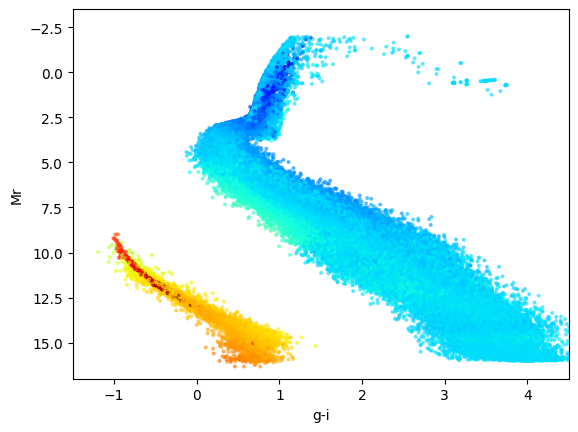

In [82]:
catalog['dMrBayes'] = catalog['Mr'] - catalog['MrTrueEst']

# test result
plt.scatter(catalog['gi0'], catalog['Mr'], c=catalog['dMrBayes'], cmap=plt.cm.jet, s=3.9, alpha=0.5)  
plt.xlabel('g-i')
plt.ylabel('Mr') 
plt.xlim(-1.5, 4.5)
plt.ylim(17, -3.5)  


In [76]:
wd = catalog[catalog['logg']>6.5]
np.min(wd['chi2min']), np.median(wd['chi2min'])
wdOK = wd[wd['chi2min']<1]
print(len(wd), len(wdOK), np.median(np.abs(wd['dMrBayes'])), np.median(np.abs(wdOK['dMrBayes'])))

9694 1764 8.89 8.89


(17.0, -3.5)

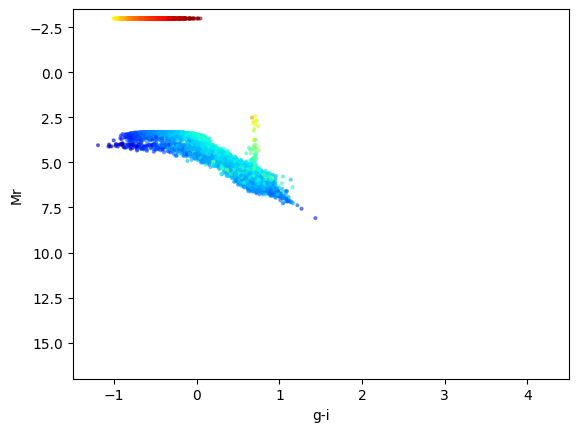

In [81]:
# test result
plt.scatter(wd['gi0'], wd['MrEst'], c=wd['dMrBayes'], cmap=plt.cm.jet, s=3.9, alpha=0.5)  
plt.xlabel('g-i')
plt.ylabel('Mr') 
plt.xlim(-1.5, 4.5)
plt.ylim(17, -3.5)  


In [83]:
msrgb = catalog[catalog['logg']<6.5]
msrgbOK = msrgb[msrgb['chi2min']<10]
msrgbOK2 = msrgbOK[np.abs(msrgbOK['dMrBayes'])<1.5]
msrgbBad = msrgb[msrgb['chi2min']>10]

print(len(catalog), len(msrgb), len(msrgbOK), len(msrgbOK2))

619576 609882 604908 599945


(17.0, -3.5)

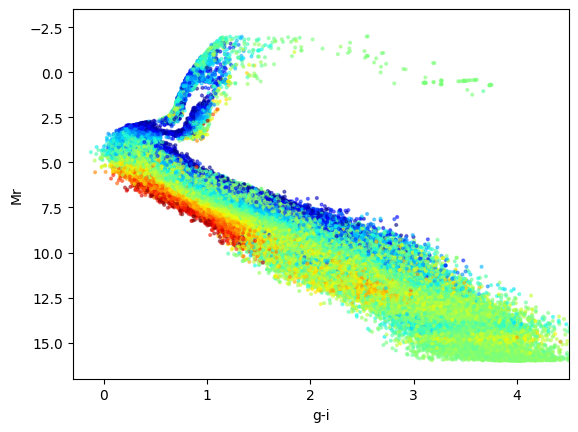

In [86]:
# test result
plt.scatter(msrgbOK2['gi0'], msrgbOK2['Mr'], c=msrgbOK2['dMrBayes'], cmap=plt.cm.jet, s=3.9, alpha=0.5)  
#plt.scatter(msrgbBad['gi0'], msrgbBad['Mr'], c=msrgbBad['dMrBayes'], cmap=plt.cm.jet, s=3.9, alpha=0.5)  
plt.xlabel('g-i')
plt.ylabel('Mr') 
plt.xlim(-0.3, 4.5)
plt.ylim(17, -3.5)  

In [ ]:
df = msrgbOK2
umagMax = 24     
df['dMr'] = df['dMrBayes'] 
df['dFeH'] = df['FeH'] - df['FeHEst']
df['dAr'] = df['Ar'] - df['ArEst']
lt.makeStatsTable3D(df, dMrname='dMr', dFeHname='dFeH', magName='umag', magThresh=umagMax, FeHthresh=-1.0, Mr1=4.0, Mr2=8.0)

(17.0, -3.5)

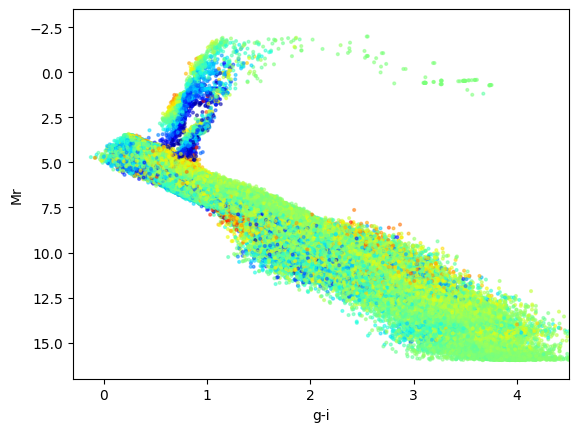

In [68]:
# test result
plt.scatter(msrgbOK2['gi0'], msrgbOK2['MrTrueEst'], c=msrgbOK2['dMrBayes'], cmap=plt.cm.jet, s=3.9, alpha=0.5)  
plt.xlabel('g-i')
plt.ylabel('Mr') 
plt.xlim(-0.3, 4.5)
plt.ylim(17, -3.5)  

In [67]:
np.min(msrgbOK2['dMrBayes']), np.median(msrgbOK2['dMrBayes']), np.max(msrgbOK2['dMrBayes']), bt.sigGzi(msrgbOK2['dMrBayes'])

(-1.4999999999999998,
 0.009999999999999787,
 1.4900000000000002,
 0.2889899999999994)

In [66]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2
# importing plotting and locus tools: 
sys.path.append('../src')
sys.path.append('../paper/notebooks')
import LocusTools as lt
import PlotTools as pt
import paperPlots as pp

In [84]:
ziL = OKlocus[OKlocus['Mr']<100]
ziL['Mr'] = ziL['MrTrue']

made plot: compare2isochrones_SDSS-DSED_1Gyr_vs_10Gyr.png


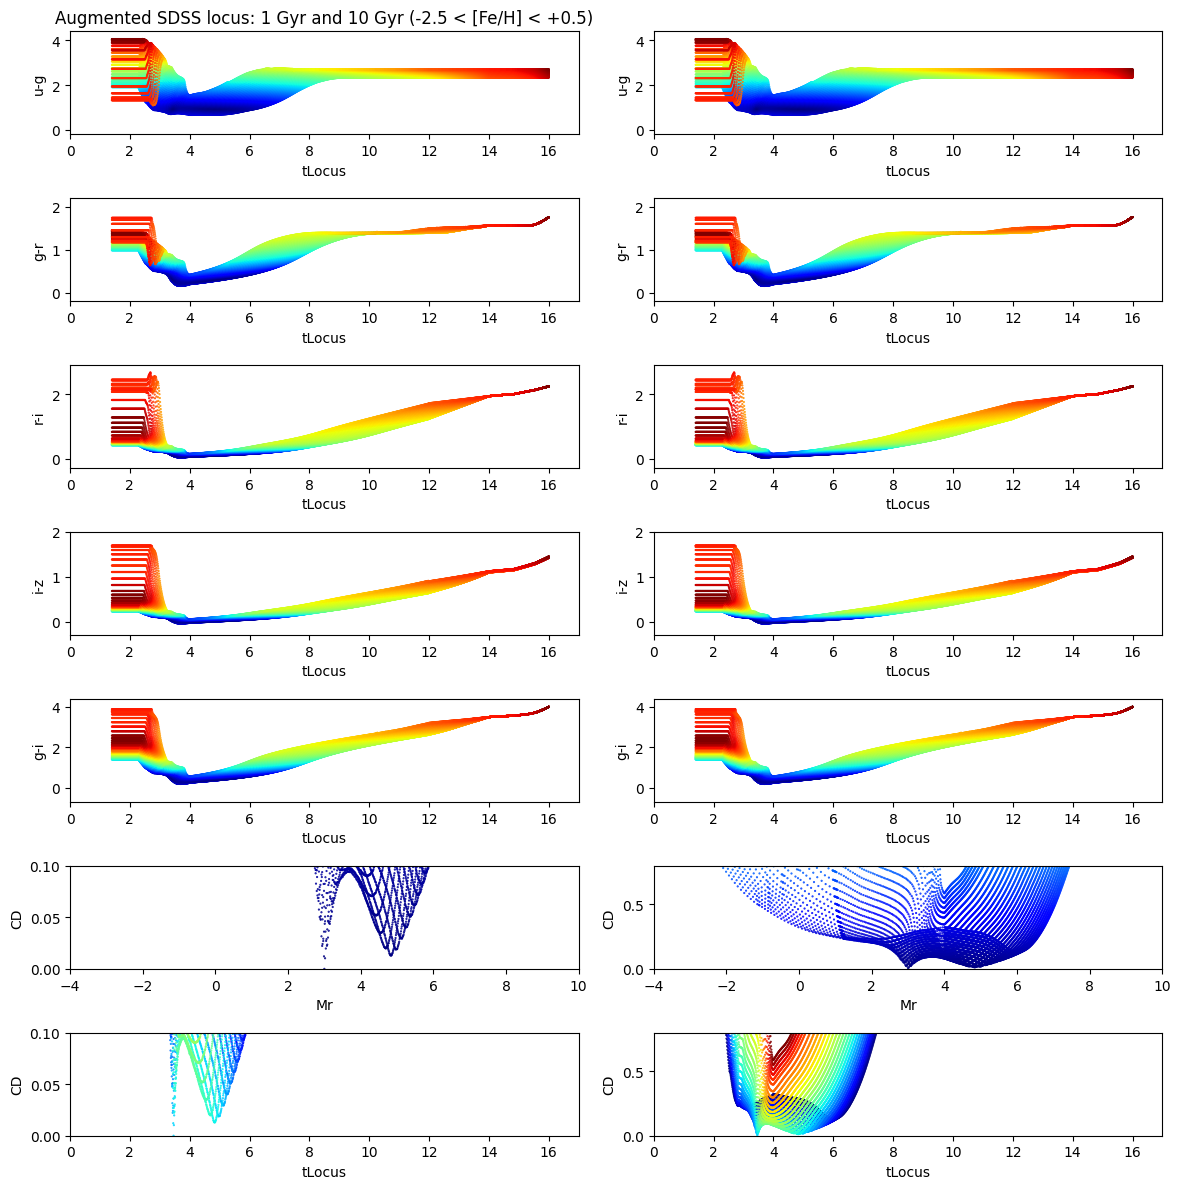

In [99]:
Pdf1 = ziL
Pdf2 = ziL 
pname = 'compare2isochrones_SDSS-DSED_1Gyr_vs_10Gyr.png'
title = 'Augmented SDSS locus: 1 Gyr and 10 Gyr (-2.5 < [Fe/H] < +0.5)'
pp.compare2isochronesColorDistance(Pdf1, Pdf2, alpha=0.95, title=title, plotname=pname) 

In [104]:
#  tLoc    Mr    FeH     ug      gr      ri      iz  
#  3.46   3.00 -1.50   0.959   0.316   0.116   0.030
k1 = OKlocus[(OKlocus['MrTrue']>2.99)&(OKlocus['MrTrue']<3.01)&(OKlocus['FeH']>-1.55)&(OKlocus['FeH']<-1.45)]